## K-nearest Neighbor Classifer

-standard knn (today

-weighted knn (today)

-exponentially weighted knn (homework)

In weighted knn: weight points by the inverse of their distances (closer points will have a greater influence)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import pairwise_distances

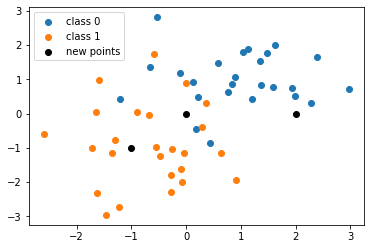

In [10]:
# toy example 
X = np.zeros((50,2))

y = np.zeros(50).astype(int)

# class 0

X[0:25] = np.random.randn(25,2) +[1,1] # random points close to (1,1)
y[0:25] = 0

X[25:50] = np.random.randn(25,2) +[-1,-1] # random points close to (-1,-1)
y[25:50] = 1

X_new = np.array([[2,0],[0,0],[-1,-1]])

plt.scatter(X[y==0,0],X[y==0,1],label = 'class 0')
plt.scatter(X[y==1,0],X[y==1,1], label = 'class 1')

plt.scatter(X_new[:,0],X_new[:,1], label = 'new points', color = 'black')

plt.legend()


In [12]:
# number of classes

labels= np.unique(y)
n_classes = len(labels)
labels

array([0, 1])

In [15]:
# distance matrix (distances from the X points to the X_new points)

dist=pairwise_distances(X,X_new)

In [18]:
# k nearest neighbors

k = 10 # we choose this

knn = np.argsort(dist,axis=0)[0:k]

In [29]:
def knn_classifier(k,X,y,X_new,weights):
    from sklearn.metrics import pairwise_distances
    
    #number of data points
    m,n = X.shape
    m_new,n_new = X_new.shape
    
    # classes and number of classes
    
    labels = np.unique(y)
    n_classes = len(labels)
    
    # distance matrix
    dist = pairwise_distances(X,X_new)
    
    #k nearest neighbors
    knn = np.argsort(dist,axis=0)[0:k]
    
    # initialize prediction vector
    y_pred = np.zeros(m_new)
    
    y_pred = np.zeros(m_new)
    
    for i in range(m_new):
        #labels
        nearest_labels = y[knn[:,i]]
        #weights
        if weights == 'uniform': #standard knn
            w = np.ones(k)
        elif weights == 'distance': # weighted knn
            w = w/dist[knn[:,i],i]
            
        y_pred[i] = np.argmax(np.bincount(nearest_labels,
                                          minlength = n_classes,
                                          weights = w))
    return y_pred, labels

In [21]:
# load the training data
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Theory/master/Data/digits.csv'
data = pd.read_csv(url)
data.head(5) # display first 5 rows of the dataset

,pixel 0,pixel 1,pixel 2,pixel 3,pixel 4,pixel 5,pixel 6,pixel 7,pixel 8,pixel 9,...,pixel 775,pixel 776,pixel 777,pixel 778,pixel 779,pixel 780,pixel 781,pixel 782,pixel 783,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9


In [23]:
X = data.iloc[:,0:784] # integer location
y = data['label'].to_numpy()

In [25]:
# rows of X are 28x28 images

row = 111
plt.imshow(X[row].reshape(28,28),cmap = 'binary')

KeyError: 111

In [26]:


# load test data
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Theory/master/Data/digits_test.csv'
test_data = pd.read_csv(url)



In [27]:


X_test = test_data.iloc[:,0:784].to_numpy() # pixels
y_test = test_data['label'].to_numpy() # labels



In [34]:
k = 10

y_test_pred,labels = knn_classifier(k,X,y,X_test, weights='uniform')



In [35]:
# percentage of correct classifications

np.mean(y_test==y_test_pred)*100

93.10000000000001

In [37]:
# confusion matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,y_test_pred)

array([[202,   0,   0,   0,   0,   0,   3,   0,   0,   0],
       [  0, 222,   1,   0,   1,   0,   0,   0,   0,   0],
       [  1,   7, 173,   1,   0,   0,   0,   2,   1,   0],
       [  0,  12,   6, 171,   0,   1,   1,   2,   2,   0],
       [  0,   7,   0,   0, 183,   0,   1,   0,   0,  13],
       [  1,   2,   0,   2,   0, 172,   4,   0,   3,   1],
       [  2,   2,   0,   0,   0,   1, 189,   0,   0,   0],
       [  0,   1,   0,   0,   2,   0,   0, 201,   0,   6],
       [  2,  15,   0,   6,   2,   1,   4,   1, 145,   7],
       [  0,   2,   0,   4,   2,   0,   0,   3,   0, 204]])